# 3 多层感知机
最简单的深层网络称为多层感知机 。多层感知机有多层神经元组成，每一次与它的上一层相连，从中接收输入；同时每一层也与它的下一层相连，影响当前层的神经元。

## 3.1 多层感知机
### 隐藏层

#### 线性模型可能会出错
线性意味着单调：任何特征的增大都会导致模型输出的增大（若权重为正），或者导致输出的减小（对应的权重为负）。

#### 网络中加入隐藏层

可以通过再网络中加入一个或多个隐藏层来克服线性模型的限制，使其能处理更普遍的函数关系类型。可以把前L-1层看作表示，把最后一层看作线性预测器。这种架构通常称为多层感知机（multilayer perceptron），缩写为MLP。

#### 从线性到非线性

矩阵$\mathbf X\in\mathbb R^{n\times d}$表示n个样本的小批量，其中每个样本具有d个输入特征。对于具有h个隐藏单元的单隐藏层多层感知机，用$\mathbf H\in\mathbb R^{n\times h}$表示隐藏层的输出，称为隐藏表示（hidden representations）。在数学和代码中，$\mathbf H$也被称为隐藏层变量（hidden-layer variable）或隐藏变量（hidden variable）。因为隐藏层和输出层是全连接的，隐藏层权重$\mathbf W^{(1)}\in\mathbb R^{d\times h}$和隐藏层偏置$\mathbf b^{(1)}\in\mathbf R^{1\times h}$以及输出层权重$\mathbf W^{(2)}\in\mathbb R^{h\times q}$和输出层偏置$\mathbf b^{(2)}\in\mathbb R^{1\times q}$。形式上，按如下方式计算单隐藏层多层感知机的输出$\mathbf O\in\mathbb R^{n\times q}$
$$
\mathbf{H=XW^{(1)}+b^{(1)}}\\

\mathbf{O=HW^{(2)}}+b^{(2)} 
$$

仿射函数的仿射函数本身就是仿射函数，故未添加非线性激活函数（activation function）$\sigma$无法发挥多层架构的潜力。激活函数的输出被称为活性值（activations）。
$$
\mathbf{H}=\sigma(\mathbf{XW^{(1)}+b^{(1)}})\\

\mathbf{O=HW^{(2)}}+b^{(2)} 
$$

#### 通用近似定理

多层感知机给定足够的神经元和正确的权重，可以对任意函数建模，尽管实际中学习改函数是很困难的。

### 激活函数

激活函数通过计算甲醛和并加上偏置来确定神经元是否应该被激活，他们将输入信号转换为输出的可微运算。大多数激活函数都是非线性的。

#### ReLU函数
最受欢迎的激活函数是修正线性单元（Rectified linear unit， ReLU），因为实现简单并在各种预测任务中表现良好。给定元素x，ReLU函数定义为改元素与0的最大值：
$$
\mathrm{ReLU}(x)=\max(x,0)
$$


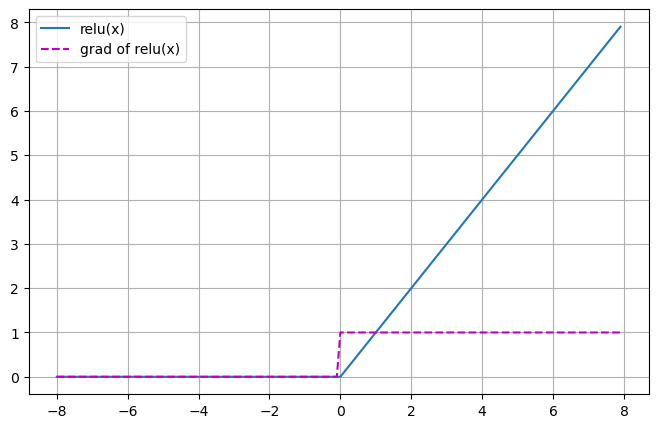

In [1]:
import torch
import sys
# sys.path.append('/home/kazundo/WorkSpace/Methods/bioinfo-dl-tutorial/src')
sys.path.append('/xjy/Project1/my_DeepLearnTest/bioinfo-dl-tutorial-main/src')

from utils.Plot import CurvePlot

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
y.backward(torch.ones_like(x), retain_graph=True)

CurvePlot(x.detach(), y.detach(), x.grad.detach(), ['relu(x)', 'grad of relu(x)'])

当输入值精确等于0时，ReLU函数不可导。此时默认使用左边的导数，即输入为0时导数为0.工程上不关心该数学问题。

使用ReLU的原因时，其求导表现特别好：要么让参数消失，要么让参数通过。这使得优化表现得更好，并且ReLU减轻了梯度消失问题

ReLU函数有许多变体，包括参数化$ReLU$（Parameterized ReLU， $pReLU$）。该变体为ReLU添加了一个线性项，因此即使参数是负的，某些信息仍然可以通过：
$$
\mathrm{pReLU}(x)=\max(0, x)+\alpha \min(0, x)
$$

#### sigmoid函数

对于一个定义域在$\mathbb R$中的输入，sigmoid函数将输入变换为区间（0，1）上的输出。因此，sigmoid通常称为挤压函数（squashing function）：将范围（-inf， inf）中的任意输入压缩到区间（0， 1）中的某个值：
$$
\mathrm{sigmoid}(x)=\frac{1}{1+\exp(-x)}
$$
阈值单元在其输入低于某个阈值时取0，输入超过阈值时取1。sigmoid函数平滑、可微的阈值单元近似。

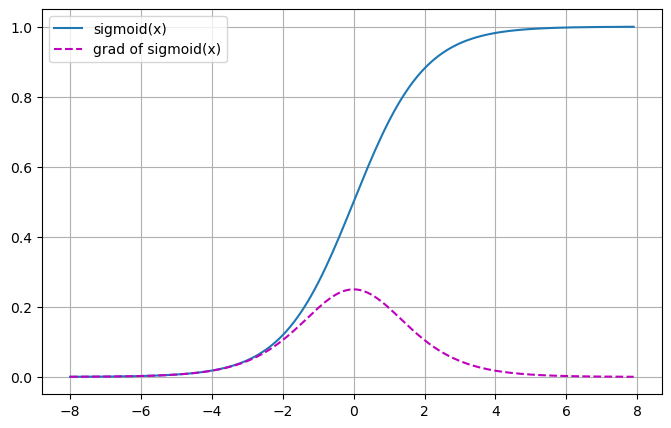

In [2]:

y = torch.sigmoid(x)
x.grad.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
CurvePlot(x.detach(), y.detach(), x.grad.detach(), ['sigmoid(x)', 'grad of sigmoid(x)'])

####  tanh函数

tanh（双曲正切）函数也能将其输入压缩转换到区间（-1，1）上，tanh函数的公式如下
$$
\tanh(x)=\frac{1-\exp(-2x)}{1-\exp(-2x)}
$$

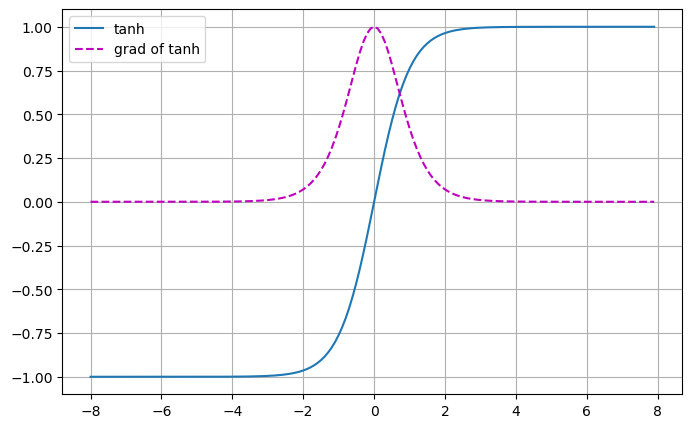

In [3]:
y = torch.tanh(x)
x.grad.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
CurvePlot(x.detach(), y.detach(), x.grad.detach(), ['tanh', 'grad of tanh'])

## 3.2 多层感知机的实现


In [4]:
from utils.DL import DataIter, TryGpu, train_class_model
from utils.Plot import LossAndAccPlot
from data.loaders import load_bulk_drug_response
from torch import nn
from sklearn.model_selection import train_test_split

drug_mat = load_bulk_drug_response()
features = torch.tensor(drug_mat.data.values, device=TryGpu()).float()
labels = torch.tensor(drug_mat.target, device=TryGpu()).flatten()
features = (features - features.mean(dim=0)) / features.std(dim=0)

X_train, X_test, y_train, y_test =  train_test_split(features, labels ,test_size=0.3)

loaders.py load successfully!


epoch:1
train loss:0.709685	train acc:0.47549
test  loss:0.695174	test  acc:0.50286
epoch:2
train loss:0.708173	train acc:0.48529
test  loss:0.694564	test  acc:0.51429
epoch:3
train loss:0.709019	train acc:0.47794
test  loss:0.693934	test  acc:0.51143
epoch:4
train loss:0.703911	train acc:0.50490
test  loss:0.693320	test  acc:0.50857
epoch:5
train loss:0.712006	train acc:0.49510
test  loss:0.692743	test  acc:0.51429
epoch:6
train loss:0.698305	train acc:0.49510
test  loss:0.692254	test  acc:0.51429
epoch:7
train loss:0.696364	train acc:0.52206
test  loss:0.691779	test  acc:0.51714
epoch:8
train loss:0.698972	train acc:0.51348
test  loss:0.691261	test  acc:0.52000
epoch:9
train loss:0.696932	train acc:0.51961
test  loss:0.690745	test  acc:0.52571
epoch:10
train loss:0.693277	train acc:0.50980
test  loss:0.690239	test  acc:0.52857
epoch:11
train loss:0.694666	train acc:0.53064
test  loss:0.689777	test  acc:0.52857
epoch:12
train loss:0.698302	train acc:0.53186
test  loss:0.689300	test  a

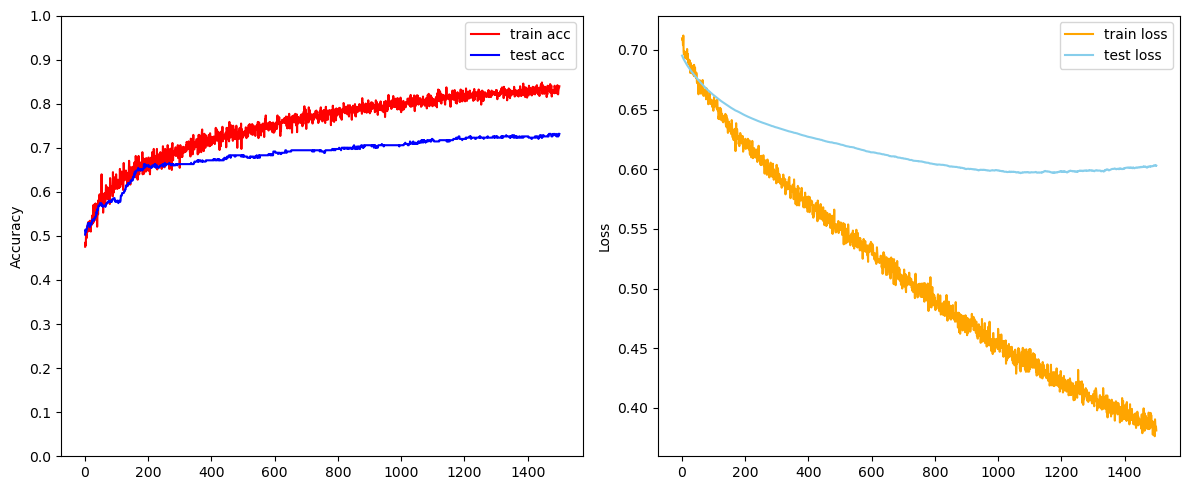

: 

In [ ]:
batch_size = 128
epochs = 1500
lr = 1e-4
p = 0.5

net = nn.Sequential(nn.Linear(features.shape[1], 512),
                    nn.LeakyReLU(),
                    nn.Dropout(p),
                    nn.Linear(512, 256),
                    nn.LeakyReLU(),
                    nn.Dropout(p),
                    nn.Linear(256, 2))
net.to(device=TryGpu())

# 初始化模型参数
for name, param in net.named_parameters():
    if name == 'weight':
        nn.init.xavier_normal_(param)

# 定义迭代器
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=1e-2)

# 定义损失
loss = nn.CrossEntropyLoss()

# 随机采样数据
train_iter = DataIter(batch_size, X_train, y_train)
test_iter = DataIter(batch_size, X_test, y_test)

net_, train_loss ,test_loss, train_acc, test_acc = train_class_model(net, train_iter, test_iter, loss, epochs, trainer)
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)